In [ ]:
# FMA tutorial
# I.M., 2025

# Examples demonstrationg usage of window weighted frequency estimation and FMA chaos indicator for symplectic mappings

# Frequency

In this example estimation of frequencies is illustrated. 

Frequencies are estimated as as window weighted phase change between iterations. Window weigting (Birkhoff averaging) demonstrates superconvergence for quasiperiodic trajectories.

In [1]:
import numpy as np
from numpy.typing import NDArray

from numba import njit

from pynamicalsys.experimental.frequency import window
from pynamicalsys.experimental.frequency import frequency

from matplotlib import pyplot as plt

Set and plot window:

In [2]:
n = 2**12
ws = window(n)

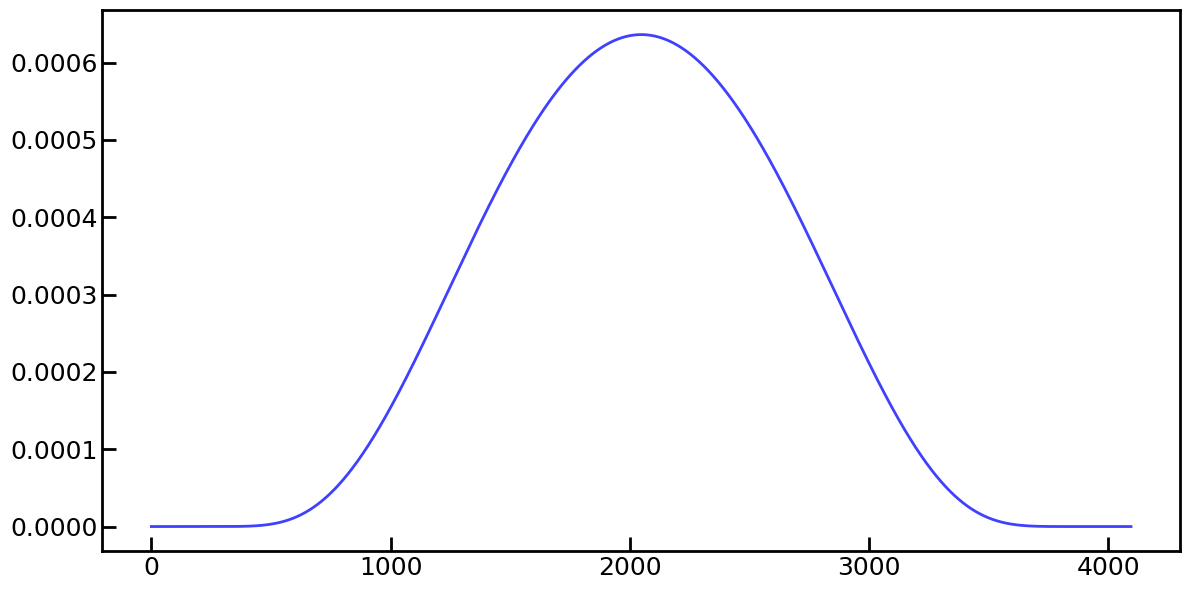

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(ws, color='blue', linewidth=2.0, alpha=0.75)
plt.setp(plt.gca().spines.values(), linewidth=2.0)
plt.gca().tick_params(width=2, labelsize=18)
plt.gca().tick_params(axis='x', length=10, direction='in')
plt.gca().tick_params(axis='y', length=10, direction='in')
plt.tight_layout()
plt.show()

Set mapping and parameters:

In [4]:
@njit
def mapping(
    xs: NDArray[np.float64],
    parameters: NDArray[np.float64]
) -> NDArray[np.float64]:
    a, b, c = parameters
    qs, ps = xs
    return np.stack((ps, -qs + a*ps + b*ps**2 + c*ps**3))

In [5]:
parameters = np.array([0.15, 1.25, -0.5])

Set initial conditions along the diagonal symmetry line:

In [6]:
qs = np.linspace(-0.350, 0.525, 2**10)
ps = np.copy(qs)
xs = np.stack([qs, ps])

Compute and plot estimated frequencies:

In [7]:
_, fs = frequency(ws, mapping, xs, parameters)

Note, `frequency` function also returns final state along with the estimated frequencies.

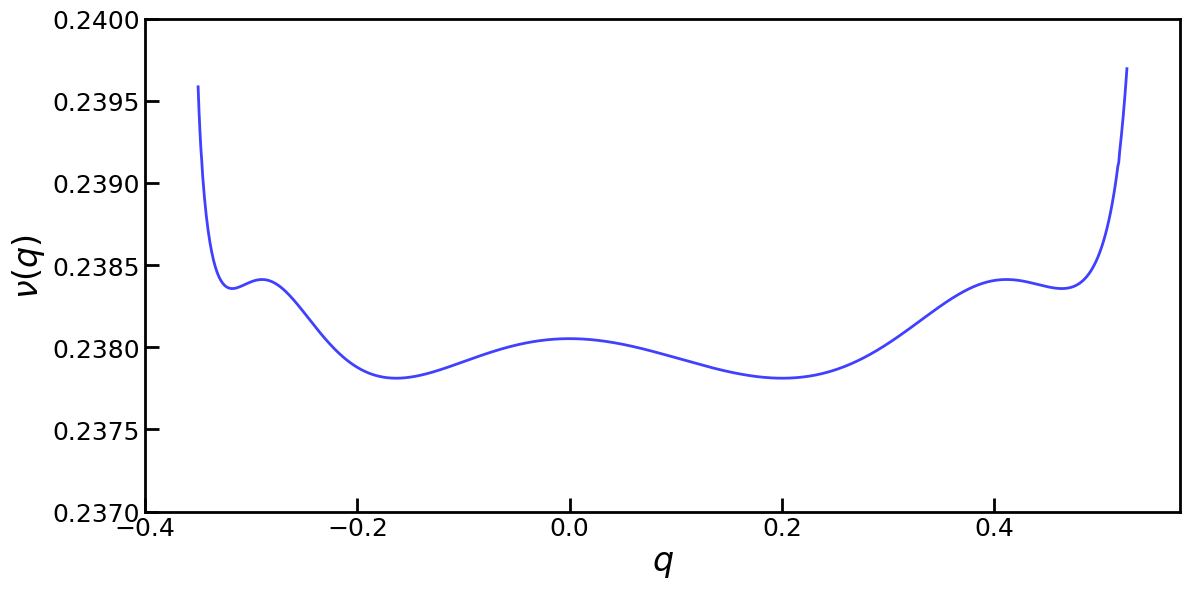

In [8]:
plt.figure(figsize=(12, 6))
plt.errorbar(qs, fs.squeeze(), color='blue', marker=None, fmt='-', lw=2.0, alpha=0.75)
plt.gca().set_xlim(-0.350 - 0.05, 0.525 + 0.05)
plt.gca().set_ylim(0.2370, 0.2400)
plt.gca().tick_params(width=2, labelsize=18)
plt.gca().tick_params(axis='x', length=10, direction='in')
plt.gca().tick_params(axis='y', length=10, direction='in')
plt.gca().set_ylabel(r'$\nu (q)$', fontsize=24)
plt.gca().set_xlabel(r'$q$', fontsize=24)
plt.setp(plt.gca().spines.values(), linewidth=2.0)
plt.tight_layout()
plt.show()

# FMA

In this example, Frequency Map Analysis (FMA) chaos indicator is illustrated.

FMA is based on the idea of (fundamental) frequencies time invariance.
In this method, frequencies are estimated over the first interval and compared with those estimated over the second interval (or several intervals).
For regular initial conditions, one would expect results from different intervals to be close.
For chaotic initial conditions, where, strictly speaking, the frequency is not well defined, the difference will be more notable.
Normally, only two intervals are used for frequency estimation, and the FMA indicator value (sometimes called frequency diffusion) is the $\log10$ of the distance in the frequency space.

FMA is known to be sensitive to both chaotic and strongly nonlinear motion. Strongly nonlinear motion can still be differentiated from chaotic motion, but this requires more intervals for frequency estimation. In the case of regular but strongly nonlinear motion, frequencies obtained over different intervals will oscillate around the true frequencies.


Import relevant functions and test mapping:

In [1]:
import numpy as np
from numpy.typing import NDArray

from numba import njit

from pynamicalsys.experimental.mappings import forward4D as mapping
from pynamicalsys.experimental.frequency import window
from pynamicalsys.experimental.frequency import frequencies

from matplotlib import pyplot as plt

# Plotting

from matplotlib import pyplot as plt
from matplotlib import colormaps

cmap = colormaps.get_cmap('viridis')
cmap.set_bad(color='lightgray')

Set mapping parameters:

In [2]:
nux, nuy = 0.168, 0.201
mux, muy = 2*np.pi*nux, 2*np.pi*nuy
cx, sx, cy, sy = np.cos(mux), np.sin(mux), np.cos(muy), np.sin(muy)
mu = 0.5

parameters = np.asarray([cx, sx, cy, sy, mu])

Set window data:

In [3]:
ws = window(2**10)

Set initial grid in `(qx, qy)` plane with small intial values for `px` and `py`:

In [4]:
n = 1001

qx = np.linspace(0.0, 0.6, n)
qy = np.linspace(0.0, 0.6, n)
qs = np.stack(np.meshgrid(qx, qy, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
ps = np.full_like(qs, 1.0E-12)
xs = np.ascontiguousarray(np.hstack([qs, ps]).T)
xs.shape

(4, 1002001)

Compute frequencies on initial the grid (two intervals):

In [5]:
%%time

fs = frequencies(2**1, ws, mapping, xs, parameters)
fs.shape

CPU times: user 1min 52s, sys: 1.06 s, total: 1min 53s
Wall time: 1min 51s


(2, 2, 1002001)

Set frequencies (first interval):

In [6]:
(fx, fy), _ = fs

Set and winsorize FMA indicator:

In [7]:
fma = np.log(1.0E-12 + np.sqrt(np.sum(np.std(fs, axis=0)**2, axis=0)))
fma[fma < -12.0] = -12.0
fma[fma > -3.0] = -3.0

Plot FMA indicator:

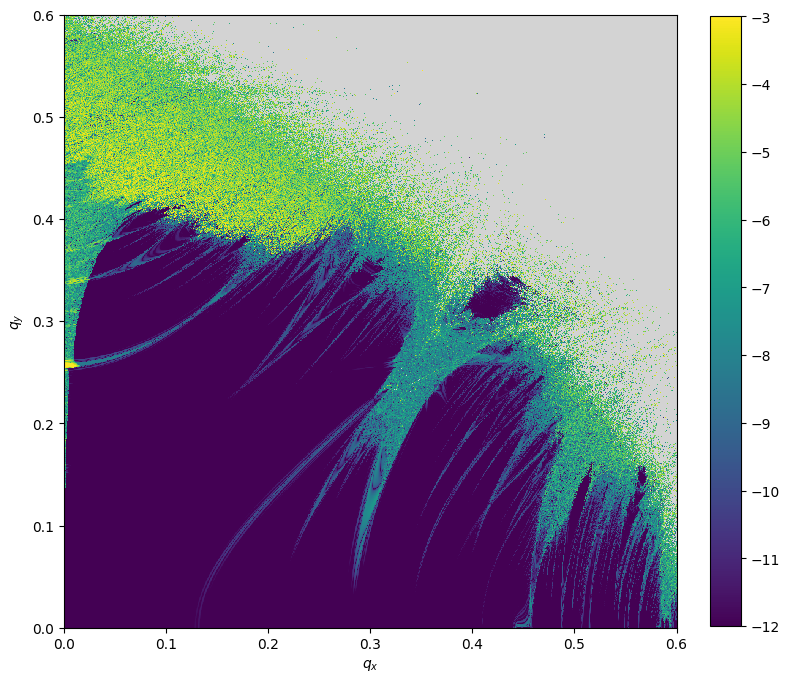

In [8]:
plt.figure(figsize=(8, 8))
plt.imshow(fma.reshape(n, n), aspect='equal', vmin=-12.0, vmax=-3.0, origin='lower', cmap=cmap, interpolation='nearest', extent=(0.0, 0.6, 0.0, 0.6))
plt.xlabel('$q_x$')
plt.ylabel('$q_y$')
plt.colorbar(location='right',fraction=0.045, pad=0.05)
plt.tight_layout()
plt.show()

Plot FMA indicator in the frequency space:

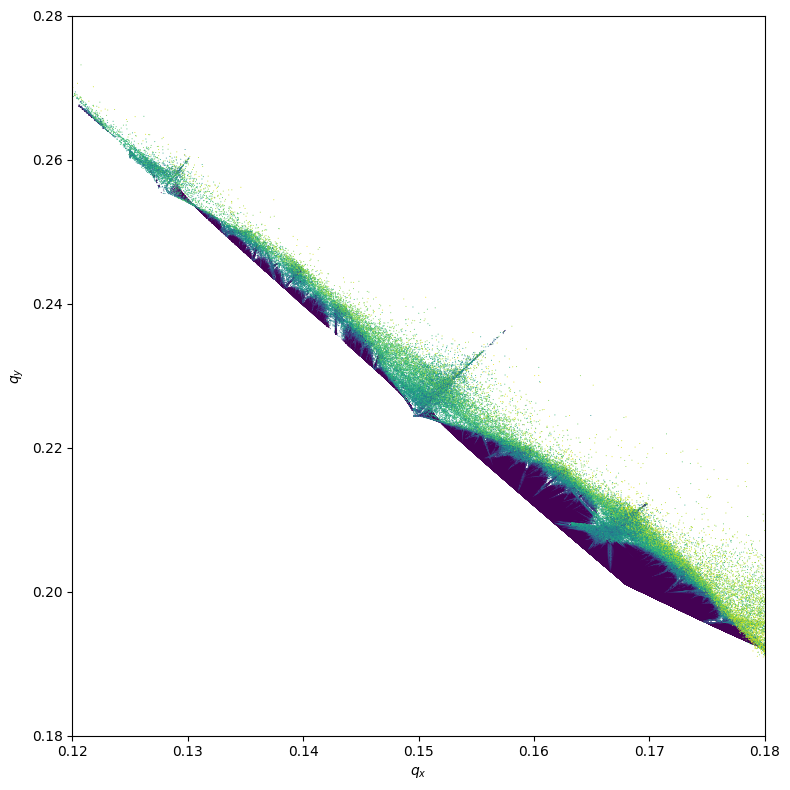

In [9]:
plt.figure(figsize=(8, 8))
plt.scatter(fx, fy, c=fma, cmap=cmap, vmin=-12.0, vmax=-3.0, s=0.5, edgecolors='none', linewidths=0, rasterized=True)
plt.xlabel('$q_x$')
plt.ylabel('$q_y$')
plt.xlim(0.12, 0.18)
plt.ylim(0.18, 0.28)
plt.tight_layout()
plt.show()

Note, that it is not guaranteed to estimate the actual fundamental frequencies.
Instead a harmonic can be estimated.
This results, in particular, in the artifact that can be seen for small horizontal and large verticle coordinates for FMA in the coordinate space.

# FMA (batched computation)

`frequencies` function relies on broadcasting to compute frequencies for several intitial conditions. To improve computation performance it is possible bo batch chunks of intilials over several threads. Chunks are expected to fit into L2 cache.

In [1]:
from typing import Callable

import numpy as np
from numpy.typing import NDArray

from numba import njit
from numba import prange

from pynamicalsys.experimental.mappings import forward4D as mapping
from pynamicalsys.experimental.frequency import window
from pynamicalsys.experimental.frequency import frequencies

from matplotlib import pyplot as plt

# Plotting

from matplotlib import pyplot as plt
from matplotlib import colormaps

cmap = colormaps.get_cmap('viridis')
cmap.set_bad(color='lightgray')

Set mapping parameters:

In [2]:
nux, nuy = 0.168, 0.201
mux, muy = 2*np.pi*nux, 2*np.pi*nuy
cx, sx, cy, sy = np.cos(mux), np.sin(mux), np.cos(muy), np.sin(muy)
mu = 0.5

parameters = np.asarray([cx, sx, cy, sy, mu])

Set window data:

In [3]:
ws = window(2**10)

Set initial grid in `(qx, qy)` plane with small intial values for `px` and `py`:

In [4]:
n = 1001

qx = np.linspace(0.0, 0.6, n)
qy = np.linspace(0.0, 0.6, n)
qs = np.stack(np.meshgrid(qx, qy, indexing='ij')).swapaxes(-1, 0).reshape(n*n, -1)
ps = np.full_like(qs, 1.0E-12)
xs = np.ascontiguousarray(np.hstack([qs, ps]).T)
xs.shape

(4, 1002001)

Compute frequencies on initial the grid using broadcasting (two intervals):

In [5]:
%%time

fs = frequencies(2**1, ws, mapping, xs, parameters)
fs.shape

CPU times: user 1min 55s, sys: 997 ms, total: 1min 56s
Wall time: 1min 55s


(2, 2, 1002001)

In [6]:
fma = np.log(1.0E-12 + np.sqrt(np.sum(np.std(fs, axis=0)**2, axis=0)))
fma[fma < -12.0] = -12.0
fma[fma > -3.0] = -3.0

Plot FMA indicator:

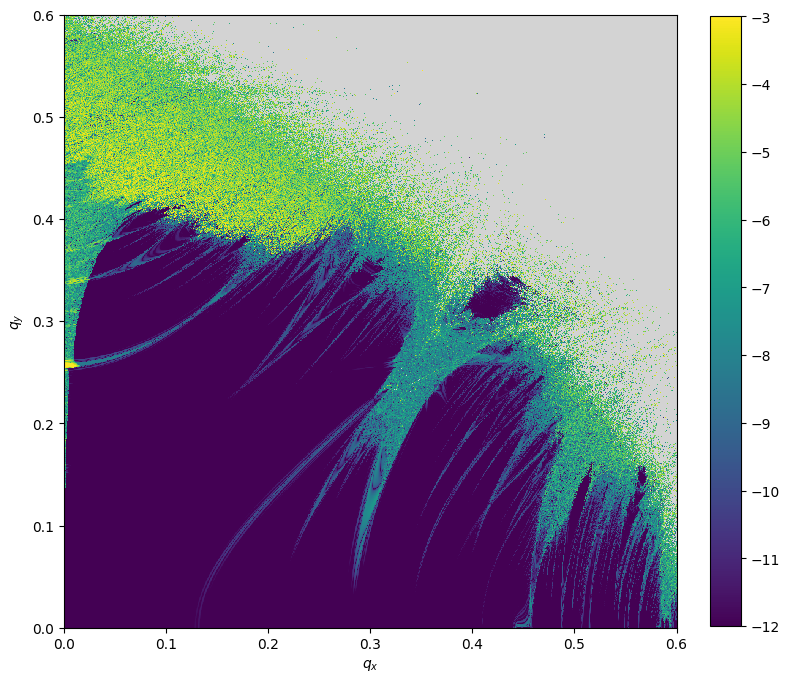

In [7]:
plt.figure(figsize=(8, 8))
plt.imshow(fma.reshape(n, n), aspect='equal', vmin=-12.0, vmax=-3.0, origin='lower', cmap=cmap, interpolation='nearest', extent=(0.0, 0.6, 0.0, 0.6))
plt.xlabel('$q_x$')
plt.ylabel('$q_y$')
plt.colorbar(location='right',fraction=0.045, pad=0.05)
plt.tight_layout()
plt.show()

Compute data using chunks: 

In [8]:
def batch_size(
    dimension: int,
    intervals: int,
    extra: int = 5,
    cache: int = 1024 << 10,
    factor: float = 0.75
) -> int:
    element = 8.0
    chunk = element*dimension*(extra + 0.5*intervals)
    return int(factor*cache/chunk)

@njit(parallel=True)
def batch_evaluate(
    batch_size: int,
    intervals: int,
    weights: NDArray[np.float64],
    mapping: Callable[[NDArray[np.float64], NDArray[np.float64]], NDArray[np.float64]],
    state: NDArray[np.float64],
    parameters: NDArray[np.float64],
) -> NDArray[np.float64]:
    dimension, size = state.shape
    result = np.empty((intervals, dimension//2, size), dtype=np.float64)
    bs = (size + batch_size - 1) // batch_size
    for b in prange(bs):
        start = b*batch_size
        end  = min(size, (b + 1)*batch_size)
        local = np.ascontiguousarray(state[:, start:end])
        result[:, :, start:end] = frequencies(intervals, weights, mapping, local, parameters)
    return result

In [9]:
%%time

fs = batch_evaluate(batch_size(4, 2**1), 2**1, ws, mapping, xs, parameters)
fs.shape

CPU times: user 3min 49s, sys: 300 ms, total: 3min 49s
Wall time: 19.2 s


(2, 2, 1002001)

In [10]:
fma = np.log(1.0E-12 + np.sqrt(np.sum(np.std(fs, axis=0)**2, axis=0)))
fma[fma < -12.0] = -12.0
fma[fma > -3.0] = -3.0

Plot FMA indicator:

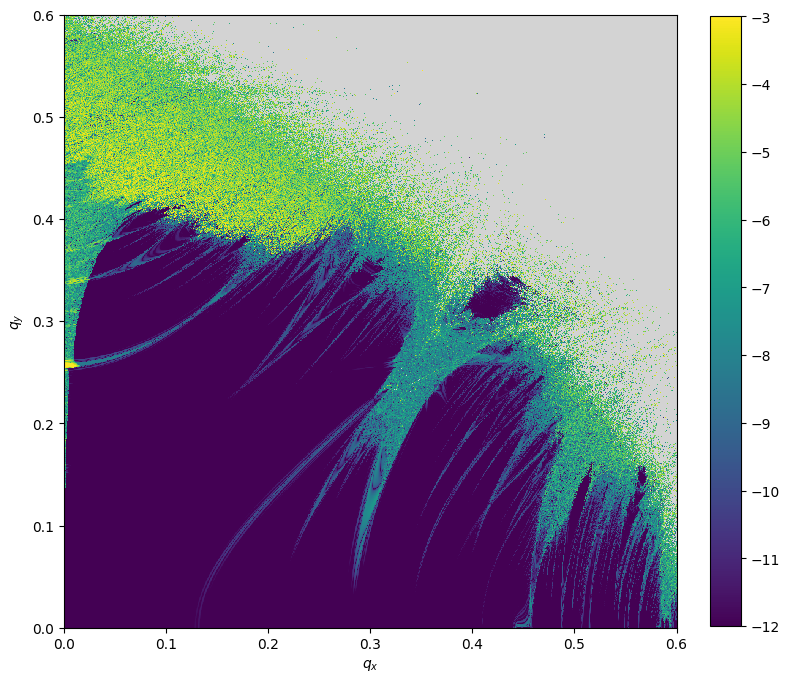

In [11]:
plt.figure(figsize=(8, 8))
plt.imshow(fma.reshape(n, n), aspect='equal', vmin=-12.0, vmax=-3.0, origin='lower', cmap=cmap, interpolation='nearest', extent=(0.0, 0.6, 0.0, 0.6))
plt.xlabel('$q_x$')
plt.ylabel('$q_y$')
plt.colorbar(location='right',fraction=0.045, pad=0.05)
plt.tight_layout()
plt.show()